

## **Project objective**
This project aims to compare annual container port activity across the economies covered by UNCTAD’s data from 2020 to 2024. Using estimated throughput in TEUs, we will identify the economies with the largest reported container volumes and examine how throughput changed over time.


## **Business questions**
1. Which economies had the highest reported container throughput in 2024?
2. How did the leading economies’ rankings change from 2020 to 2024?
3. Among economies with reported values in both 2020 and 2024, which had the largest absolute and percentage changes?
4. How did throughput change year by year among economies with reported values for all five years?
5. Among economies with reported throughput in every year from 2020 to 2024, which had the most consistent and the most variable year-over-year percentage changes?

## **Scope**
The dataset reports country-level container port totals. Throughput represents container handling associated with loading, unloading, repositioning, and transshipment. One 20-foot container equals 1 TEU; one 40-foot container equals 2 TEUs. The analysis compares economies, not individual ports or shipping companies. It does not measure cargo weight, trade value, company revenue, or port capacity. UNCTAD notes that some smaller ports may not be included. citeturn19search0

## **Comparison rules**
- Missing values are unavailable, not zero.
- Questions 4 and 5 use only economies with reported values in every year from 2020 through 2024.
- Percentage changes require a reported, nonzero value in 2020.

## **Planned visualizations**
To communicate the findings clearly, we plan to use a variety of charts matched to the questions:

- A horizontal bar chart to compare the top economies in 2024.
- Line charts to show throughput trends over 2020–2024.
- A rank heatmap to show how economy rankings changed over time.
- A diverging bar chart to compare 2020–2024 increases and decreases.
- A dot plot to compare relative throughput variability among economies with complete data.

We will finalize the charts after analysis and use reported values only; unavailable values will not be treated as zero.

## **Data Source and Measure**

The analysis uses UNCTADstat’s *Container port throughput, annual (analytical)* dataset. It covers reported throughput for individual economies from 2020 through 2024.

Throughput is measured in twenty-foot equivalent units (TEUs). One 20-foot container equals 1 TEU, and one 40-foot container equals 2 TEUs. The analysis compares reported container throughput by economy; it does not compare individual shipping companies.

## **Data Quality Checks**

The dataset contains records for 136 economies across 2020–2024. All 136 have a row for each year, with no duplicate rows or duplicate economy-year records. Of the 680 economy-year values, 88 are unavailable: 78 are labeled “Not publishable” and 10 “Not applicable.” These were left as missing, not treated as zero.

The analysis uses 592 reported numeric values from 130 economies. The reported values passed checks for numeric format, finite values, and nonnegative throughput. A complete reported series for all five years was available for 101 economies.

The UNCTAD container port throughput ZIP file has been uploaded to Colab. This cell checks the archive, lists its contents, and extracts the CSV and metadata files into a working folder. The selected years are 2020–2024.

In [16]:
from pathlib import Path
import zipfile

zip_files = list(Path("/content").glob("*.zip"))
if not zip_files:
    raise FileNotFoundError("No ZIP file found in /content")

zip_path = max(zip_files, key=lambda file: file.stat().st_mtime)
extract_folder = Path("/content/port_throughput")

print("Using:", zip_path.name)

with zipfile.ZipFile(zip_path) as archive:
    print("Archive contents:", archive.namelist())
    archive.extractall(extract_folder)

print("Extracted files:")
for file in extract_folder.rglob("*"):
    if file.is_file():
        print(file.name, "—", file.stat().st_size, "bytes")

Using: US.ContPortThroughput_20261006_085212.zip
Archive contents: ['US.ContPortThroughput_20261006_085212_metadata.txt', 'US.ContPortThroughput_20261006_085212.csv']
Extracted files:
US.ContPortThroughput_20261006_085212_metadata.txt — 132 bytes
US.ContPortThroughput_20261006_085212.csv — 20052 bytes


### **Check Missing Country-Year Values**

This step excludes the “Individual economies” placeholder and checks which country-year throughput values are missing. It also summarizes UNCTAD’s missing-value labels so we can understand why values are unavailable. Missing values are kept separate from zero throughput.

In [17]:
import pandas as pd

csv_path = next(extract_folder.rglob("*.csv"))
df = pd.read_csv(csv_path)

value_col = "TEU_Twenty_foot_Equivalent_Unit_Value"

print("File:", csv_path.name)
print("Rows and columns:", df.shape)
print("Years:", sorted(df["Year"].dropna().unique()))
print("Unique economy labels:", df["Economy_Label"].nunique())
print("Example labels:", sorted(df["Economy_Label"].dropna().unique())[:15])
print("India included:", "India" in set(df["Economy_Label"].dropna()))
print("Missing TEU values:", df[value_col].isna().sum())
print("Duplicate economy-year rows:",
      df.duplicated(["Economy_Label", "Year"]).sum())

display(df.head())

File: US.ContPortThroughput_20261006_085212.csv
Rows and columns: (685, 5)
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Unique economy labels: 137
Example labels: ['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Aruba', 'Australia', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belgium', 'Belize', 'Brazil', 'Brunei Darussalam']
India included: True
Missing TEU values: 93
Duplicate economy-year rows: 0


,Economy_Label,Year,TEU_Twenty_foot_Equivalent_Unit_Value,TEU_Twenty_foot_Equivalent_Unit_Footnote,TEU_Twenty_foot_Equivalent_Unit_MissingValue
0,Individual economies,2020,NaN,NaN,Not applicable
1,Individual economies,2021,NaN,NaN,Not applicable
2,Individual economies,2022,NaN,NaN,Not applicable
3,Individual economies,2023,NaN,NaN,Not applicable
4,Individual economies,2024,NaN,NaN,Not applicable


### **Review Missing Country-Year Values**

This step counts missing throughput values and shows UNCTAD’s reason labels. “Not publishable” and “Not applicable” indicate unavailable values; they are not zero throughput.

In [18]:
value_col = "TEU_Twenty_foot_Equivalent_Unit_Value"
missing_col = "TEU_Twenty_foot_Equivalent_Unit_MissingValue"

country_df = df[df["Economy_Label"] != "Individual economies"].copy()
missing_rows = country_df[country_df[value_col].isna()]

print("Economies:", country_df["Economy_Label"].nunique())
print("Missing country-year values:", len(missing_rows))
print("\nMissing-value labels:")
print(missing_rows[missing_col].value_counts(dropna=False))

display(missing_rows[["Economy_Label", "Year", missing_col]].head(20))

Economies: 136
Missing country-year values: 88

Missing-value labels:
TEU_Twenty_foot_Equivalent_Unit_MissingValue
Not publishable    78
Not applicable     10
Name: count, dtype: int64


,Economy_Label,Year,TEU_Twenty_foot_Equivalent_Unit_MissingValue
9,Albania,2024,Not publishable
11,Algeria,2021,Not publishable
59,Barbados,2024,Not publishable
69,Belize,2024,Not publishable
79,Brunei Darussalam,2024,Not publishable
105,Cayman Islands,2020,Not publishable
106,Cayman Islands,2021,Not publishable
108,Cayman Islands,2023,Not publishable
159,Cuba,2024,Not publishable
170,Dem. Rep. of the Congo,2020,Not publishable


### **Prepare Records with Available Throughput Values**

This step creates a working table for analysis by keeping records with reported numeric TEU values. Unavailable values are excluded from calculations, not treated as zero.

In [19]:
analysis_df = country_df.copy()
analysis_df[value_col] = pd.to_numeric(analysis_df[value_col], errors="coerce")
analysis_df = analysis_df.dropna(subset=[value_col]).copy()

print("Available country-year records:", len(analysis_df))
print("Economies with reported values:", analysis_df["Economy_Label"].nunique())
print("Years included:", sorted(analysis_df["Year"].unique()))

display(analysis_df.head())

Available country-year records: 592
Economies with reported values: 130
Years included: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,Economy_Label,Year,TEU_Twenty_foot_Equivalent_Unit_Value,TEU_Twenty_foot_Equivalent_Unit_Footnote,TEU_Twenty_foot_Equivalent_Unit_MissingValue
5,Albania,2020,138477.0,NaN,NaN
6,Albania,2021,144129.0,NaN,NaN
7,Albania,2022,132965.0,NaN,NaN
8,Albania,2023,184017.0,NaN,NaN
10,Algeria,2020,1541273.0,NaN,NaN


### **Final Data Quality Audit**

This step checks missing values, duplicate records, year coverage, and throughput values across the dataset. It also checks whether unavailable throughput values have a reason label. Blank footnotes may be normal and are not automatically data errors.

In [20]:
import pandas as pd
import numpy as np

value_col = "TEU_Twenty_foot_Equivalent_Unit_Value"
missing_col = "TEU_Twenty_foot_Equivalent_Unit_MissingValue"

print("Missing values by column:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

# Exclude the summary placeholder row from economy-level checks
country_only = df[df["Economy_Label"] != "Individual economies"].copy()

print(
    "Duplicate economy-year rows:",
    country_only.duplicated(["Economy_Label", "Year"]).sum()
)

expected_years = {2020, 2021, 2022, 2023, 2024}
observed_years = set(pd.to_numeric(country_only["Year"], errors="coerce").dropna())

print("\nYears found:", sorted(observed_years))
print("Unexpected years:", sorted(observed_years - expected_years))

# Check whether each economy has a row for all five years
years_per_economy = country_only.groupby("Economy_Label")["Year"].nunique()
incomplete_economies = years_per_economy[years_per_economy != 5]

print("Economies without rows for all 5 years:", len(incomplete_economies))

# Check throughput values
raw_values = country_only[value_col]
numeric_values = pd.to_numeric(raw_values, errors="coerce")

invalid_values = raw_values.notna() & numeric_values.isna()
non_finite_values = numeric_values.notna() & ~np.isfinite(numeric_values)

print("\nInvalid non-numeric throughput values:", invalid_values.sum())
print("Non-finite throughput values:", non_finite_values.sum())
print("Negative throughput values:", numeric_values.lt(0).sum())
print("Zero throughput values:", numeric_values.eq(0).sum())

# Check that missing throughput values have reason labels
reason_labels = country_only[missing_col]

print(
    "Missing throughput values without a reason label:",
    (numeric_values.isna() & reason_labels.isna()).sum()
)
print(
    "Reported throughput values with a missing-value label:",
    (numeric_values.notna() & reason_labels.notna()).sum()
)

Missing values by column:
Economy_Label                                     0
Year                                              0
TEU_Twenty_foot_Equivalent_Unit_Value            93
TEU_Twenty_foot_Equivalent_Unit_Footnote        676
TEU_Twenty_foot_Equivalent_Unit_MissingValue    592
dtype: int64

Exact duplicate rows: 0
Duplicate economy-year rows: 0

Years found: [2020, 2021, 2022, 2023, 2024]
Unexpected years: []
Economies without rows for all 5 years: 0

Invalid non-numeric throughput values: 0
Non-finite throughput values: 0
Negative throughput values: 0
Zero throughput values: 0
Missing throughput values without a reason label: 0
Reported throughput values with a missing-value label: 0


### **Data Quality Findings**

- The dataset contains 136 economies with rows for all five years (2020–2024); no duplicate rows or economy-year records were found.
- There are 592 reported numeric TEU values across 130 economies. The 88 missing country-year values are labeled “Not publishable” (78) or “Not applicable” (10).
- Reported values passed the checks for numeric, finite, and nonnegative values; none were zero.
- Missing footnotes and blank missing-value labels on records with reported TEU values are expected. Missing throughput values remain unavailable, not zero.

### **Q1** **-** **Which economies had the highest reported container throughput in 2024?**

This step ranks the ten economies with the highest reported container port throughput in 2024, the latest year in our dataset. It uses reported TEU values only; unavailable values are excluded, not treated as zero.

**What throughput means:** An “economy” is a country or territory entry in the dataset. Container port throughput is the estimated annual volume handled at its ports, measured in TEUs: a 20-foot container equals 1 TEU, and a 40-foot container equals 2 TEUs. It measures port activity, not unique containers or company performance.

In [21]:
latest_year = analysis_df["Year"].max()

top_10_latest = (
    analysis_df[analysis_df["Year"] == latest_year]
    .nlargest(10, value_col)[["Economy_Label", "Year", value_col]]
    .reset_index(drop=True)
)

top_10_latest.insert(0, "Rank", range(1, len(top_10_latest) + 1))

display(top_10_latest)

,Rank,Economy_Label,Year,TEU_Twenty_foot_Equivalent_Unit_Value
0,1,China,2024,299703800.0
1,2,United States,2024,59707490.0
2,3,Singapore,2024,41124100.0
3,4,Republic of Korea,2024,31850924.0
4,5,Malaysia,2024,30659850.0
5,6,Viet Nam,2024,24423183.0
6,7,India,2024,23898000.0
7,8,United Arab Emirates,2024,23466906.0
8,9,Japan,2024,21886683.0
9,10,Spain,2024,18114517.0


### **Q1 Finding — 2024 Throughput Leaders**

China had the highest reported container port throughput in 2024, at approximately 299.7 million TEUs—about five times the United States’ 59.7 million. Singapore ranked third at 41.1 million TEUs. These are economy-level throughput estimates, not measures of company performance.

### **2024 Top 10 Bar Chart**

This chart compares the ten economies with the highest reported throughput in 2024. Values are shown in millions of TEUs for readability.

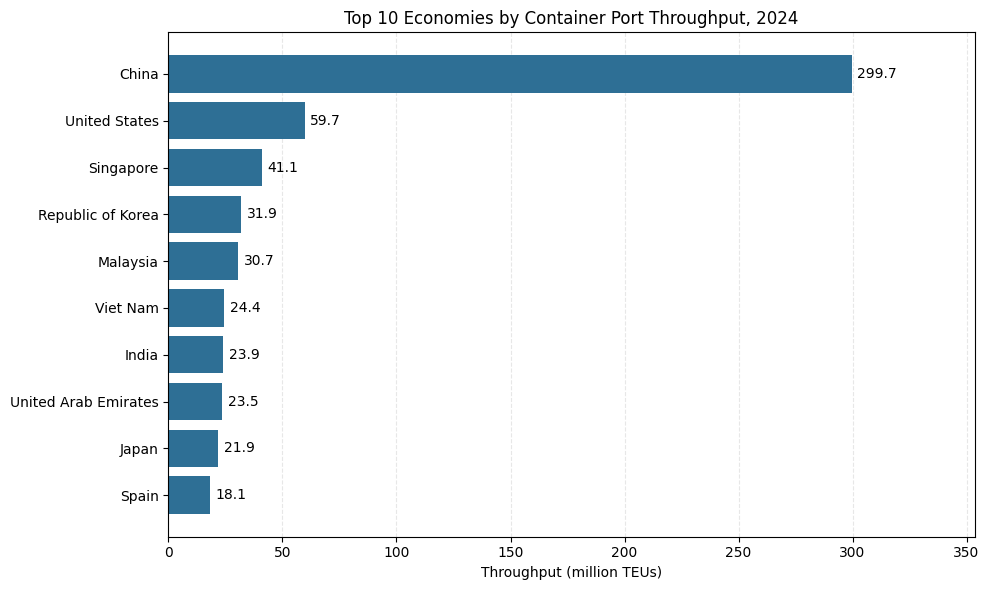

In [22]:
import matplotlib.pyplot as plt

chart_df = top_10_latest.sort_values(value_col).copy()
throughput_millions = chart_df[value_col] / 1_000_000

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    chart_df["Economy_Label"],
    throughput_millions,
    color="#2E6F95"
)

ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set_xlim(0, throughput_millions.max() * 1.18)
ax.set_xlabel("Throughput (million TEUs)")
ax.set_title("Top 10 Economies by Container Port Throughput, 2024")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### **Q2 — How did the 2024 leaders’ rankings change from 2020 to 2024?**

This step tracks the ten economies that ranked highest in 2024 and shows their ranks in each year from 2020 to 2024. Each rank compares an economy with all economies that have a reported throughput value that year. A blank means no value was reported for that economy-year.

In [23]:
yearly_rankings = analysis_df.copy()

yearly_rankings["Rank"] = (
    yearly_rankings.groupby("Year")[value_col]
    .rank(method="min", ascending=False)
    .astype("Int64")
)

economies_2024 = top_10_latest["Economy_Label"].tolist()

rank_trend = (
    yearly_rankings[yearly_rankings["Economy_Label"].isin(economies_2024)]
    .pivot(index="Economy_Label", columns="Year", values="Rank")
    .reindex(economies_2024)
)

display(rank_trend)

Year,2020,2021,2022,2023,2024
Economy_Label,,,,,
China,1,1,1,1,1
United States,2,2,2,2,2
Singapore,3,3,3,3,3
Republic of Korea,4,4,4,4,4
Malaysia,5,5,5,5,5
Viet Nam,11,7,7,9,6
India,9,8,9,6,7
United Arab Emirates,7,9,8,7,8
Japan,6,6,6,8,9


### **Q2 Finding — Ranking Changes, 2020–2024**

The top five economies retained the same ranks in every year shown. Vietnam had the largest rise among the 2024 top ten, moving from 11th in 2020 to 6th in 2024. Japan moved from 6th to 9th, while India rose from 9th to 7th. Spain ranked 10th in both 2020 and 2024, despite a brief move to 11th in 2021.

These are relative ranks among economies with reported values in each year. A rank change can reflect changes in reported throughput and differences in which values are available.

### **Rank Heatmap**

This heatmap shows how the 2024 top ten economies ranked from 2020 to 2024. Rank 1 is highest; greener cells indicate stronger ranks, and redder cells indicate lower ranks.

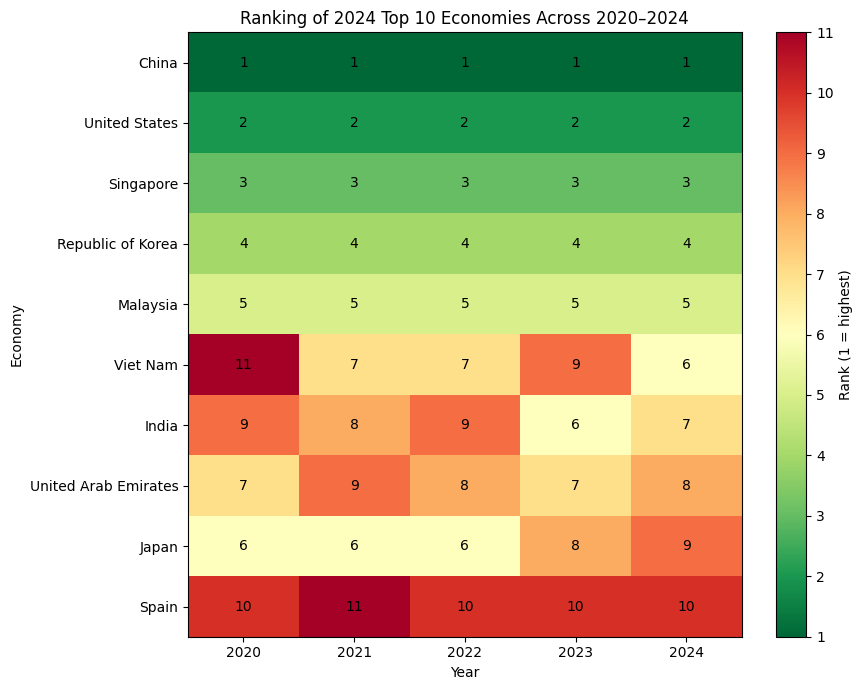

In [24]:
import matplotlib.pyplot as plt
import numpy as np

rank_values = rank_trend.to_numpy(dtype=float)
max_rank = int(np.nanmax(rank_values))

cmap = plt.get_cmap("RdYlGn_r").copy()
cmap.set_bad("#d9d9d9")

fig, ax = plt.subplots(figsize=(9, 7))

heatmap = ax.imshow(
    np.ma.masked_invalid(rank_values),
    aspect="auto",
    cmap=cmap,
    vmin=1,
    vmax=max_rank
)

ax.set_xticks(range(len(rank_trend.columns)))
ax.set_xticklabels(rank_trend.columns)
ax.set_yticks(range(len(rank_trend.index)))
ax.set_yticklabels(rank_trend.index)

for row in range(rank_values.shape[0]):
    for col in range(rank_values.shape[1]):
        value = rank_values[row, col]
        if not np.isnan(value):
            ax.text(col, row, f"{int(value)}", ha="center", va="center")

ax.set_title("Ranking of 2024 Top 10 Economies Across 2020–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Economy")

colorbar = fig.colorbar(heatmap, ax=ax, ticks=range(1, max_rank + 1))
colorbar.set_label("Rank (1 = highest)")

plt.tight_layout()
plt.show()

### **Q3** **— Which comparable economies had the largest absolute and percentage changes from 2020 to 2024?**

This step compares throughput for economies with reported values in both 2020 and 2024. Absolute change shows the difference in TEUs; percentage change compares that difference with the 2020 value. We’ll review both because a large percentage change can come from a small 2020 baseline.

In [25]:
endpoint_values = (
    analysis_df[analysis_df["Year"].isin([2020, 2024])]
    .pivot(index="Economy_Label", columns="Year", values=value_col)
)

comparison = (
    endpoint_values
    .dropna(subset=[2020, 2024])
    .rename(columns={2020: "TEU_2020", 2024: "TEU_2024"})
    .reset_index()
)

comparison = comparison[comparison["TEU_2020"] != 0].copy()
comparison["Absolute_Change_TEU"] = comparison["TEU_2024"] - comparison["TEU_2020"]
comparison["Percentage_Change"] = (
    comparison["Absolute_Change_TEU"] / comparison["TEU_2020"] * 100
)

print("Economies with reported values in both years:", len(comparison))

columns_to_show = [
    "Economy_Label",
    "TEU_2020",
    "TEU_2024",
    "Absolute_Change_TEU",
    "Percentage_Change"
]

print("\nLargest absolute increases:")
display(comparison.nlargest(10, "Absolute_Change_TEU")[columns_to_show].round(1))

print("\nLargest absolute decreases:")
display(comparison.nsmallest(10, "Absolute_Change_TEU")[columns_to_show].round(1))

print("\nLargest percentage increases:")
display(comparison.nlargest(10, "Percentage_Change")[columns_to_show].round(1))

print("\nLargest percentage decreases:")
display(comparison.nsmallest(10, "Percentage_Change")[columns_to_show].round(1))

Economies with reported values in both years: 105

Largest absolute increases:


Year,Economy_Label,TEU_2020,TEU_2024,Absolute_Change_TEU,Percentage_Change
17,China,240480000.0,299703800.0,59223800.0,24.6
103,Viet Nam,16394723.0,24423183.0,8028460.0,49.0
101,United States,53059014.0,59707490.0,6648476.0,12.5
46,India,17597062.0,23898000.0,6300938.0,35.8
63,Morocco,7000928.0,11789130.0,4788202.0,68.4
98,United Arab Emirates,18720000.0,23466906.0,4746906.0,25.4
87,Singapore,36870900.0,41124100.0,4253200.0,11.5
58,Malaysia,26669483.0,30659850.0,3990367.0,15.0
10,Brazil,10450632.0,13893906.0,3443274.0,32.9
79,Republic of Korea,28834192.0,31850924.0,3016732.0,10.5



Largest absolute decreases:


Year,Economy_Label,TEU_2020,TEU_2024,Absolute_Change_TEU,Percentage_Change
18,"China, Hong Kong SAR",17953000.0,13690000.0,-4263000.0,-23.7
85,Saudi Arabia,9330437.0,8029571.0,-1300866.0,-13.9
70,Oman,5146009.0,4246786.0,-899223.0,-17.5
19,"China, Taiwan Province of",14593553.0,13933246.0,-660307.0,-4.5
39,Germany,13946212.0,13294081.0,-652131.0,-4.7
41,Greece,6188061.0,5691448.0,-496613.0,-8.0
64,Myanmar,1095247.0,782951.0,-312296.0,-28.5
9,Belgium,12697162.0,12395047.0,-302115.0,-2.4
66,Netherlands (Kingdom of the),14757227.0,14517179.0,-240048.0,-1.6
3,Argentina,1705390.0,1471434.0,-233956.0,-13.7



Largest percentage increases:


Year,Economy_Label,TEU_2020,TEU_2024,Absolute_Change_TEU,Percentage_Change
23,Cote d'Ivoire,979517.0,1802000.0,822483.0,84.0
63,Morocco,7000928.0,11789130.0,4788202.0,68.4
57,Lithuania,639006.0,1068771.0,429765.0,67.3
13,Cambodia,641842.0,1030000.0,388158.0,60.5
81,Romania,643025.0,989795.0,346770.0,53.9
28,Djibouti,860000.0,1293000.0,433000.0,50.3
103,Viet Nam,16394723.0,24423183.0,8028460.0,49.0
54,Kenya,1359579.0,2005076.0,645497.0,47.5
102,Uruguay,764797.0,1115000.0,350203.0,45.8
51,Jamaica,1631011.0,2349405.0,718394.0,44.0



Largest percentage decreases:


Year,Economy_Label,TEU_2020,TEU_2024,Absolute_Change_TEU,Percentage_Change
64,Myanmar,1095247.0,782951.0,-312296.0,-28.5
18,"China, Hong Kong SAR",17953000.0,13690000.0,-4263000.0,-23.7
70,Oman,5146009.0,4246786.0,-899223.0,-17.5
14,Cameroon,421854.0,350000.0,-71854.0,-17.0
85,Saudi Arabia,9330437.0,8029571.0,-1300866.0,-13.9
3,Argentina,1705390.0,1471434.0,-233956.0,-13.7
77,Puerto Rico,1490218.0,1300000.0,-190218.0,-12.8
34,Finland,1496192.0,1317452.0,-178740.0,-11.9
7,Bahrain,464010.0,409382.0,-54628.0,-11.8
104,Yemen,423393.0,380000.0,-43393.0,-10.2


###**  2020–2024 Throughput Changes**

These charts compare the five largest increases and decreases among economies with reported values in both 2020 and 2024. The first panel shows absolute changes in millions of TEUs; the second shows percentage changes. Percentage changes should be read alongside absolute changes because a small 2020 value can produce a large percentage.

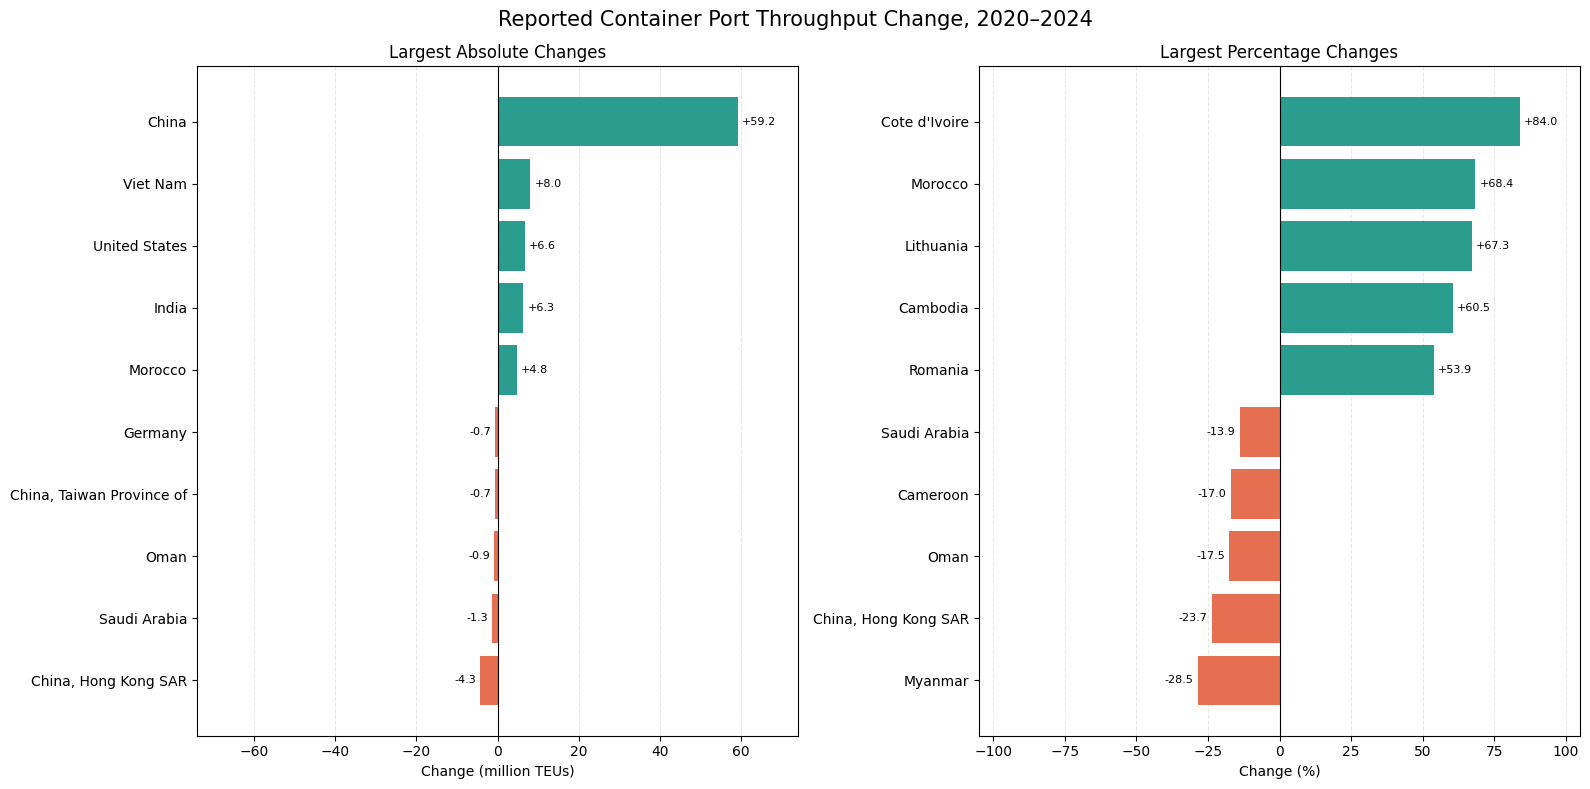

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_change_panel(ax, metric, divisor, title, xlabel):
    increases = comparison.nlargest(5, metric)
    decreases = comparison.nsmallest(5, metric)
    selected = pd.concat([decreases, increases]).sort_values(metric)

    values = selected[metric] / divisor
    colors = ["#2A9D8F" if value >= 0 else "#E76F51" for value in values]

    bars = ax.barh(selected["Economy_Label"], values, color=colors)
    labels = [f"{value:+.1f}" for value in values]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=8)

    limit = max(abs(values.max()), abs(values.min())) * 1.25
    ax.set_xlim(-limit, limit)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_change_panel(
    axes[0],
    "Absolute_Change_TEU",
    1_000_000,
    "Largest Absolute Changes",
    "Change (million TEUs)"
)

plot_change_panel(
    axes[1],
    "Percentage_Change",
    1,
    "Largest Percentage Changes",
    "Change (%)"
)

fig.suptitle("Reported Container Port Throughput Change, 2020–2024", fontsize=15)
plt.tight_layout()
plt.show()

### How to Read the Q3 Chart

The chart has two panels. The **left panel** shows the absolute difference between 2020 and 2024, in millions of TEUs. The **right panel** shows that difference as a percentage of the economy’s 2020 throughput. Bars extending right from zero show increases; bars extending left show decreases. Longer bars represent larger changes within that panel. The comparison includes only economies with reported values in both years.

### **Q3 Finding — Throughput Changes, 2020–2024**

Among the 105 economies with reported values in both years, **China** had the largest absolute increase: **59.2 million TEUs**. **Cote d'Ivoire** had the largest percentage increase (**84.0%**), rising by about **822,000 TEUs**; **Morocco** ranked highly on both measures, increasing by **4.8 million TEUs (68.4%)**.

For decreases, **China, Hong Kong SAR** had the largest absolute decline (**4.3 million TEUs**), while **Myanmar** had the largest percentage decline (**28.5%**, or about **312,000 TEUs**). The leaders differ because absolute change measures volume, while percentage change is relative to 2020 throughput. These endpoint comparisons show what changed, not why.

### **Q4 - How did combined throughput change each year among economies with reported values for all five years?**

This step includes only economies with reported TEU values for every year from 2020 to 2024. The line chart shows their combined reported throughput by year. Because some economies are excluded, this is not a global total.

Economies with reported values in all five years: 101


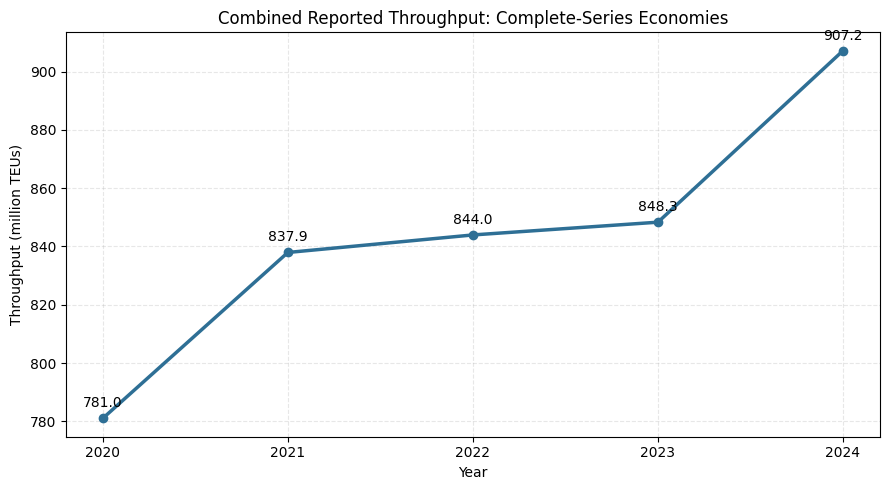

In [27]:
import matplotlib.pyplot as plt

years_per_economy = analysis_df.groupby("Economy_Label")["Year"].nunique()
complete_economies = years_per_economy[years_per_economy == 5].index

complete_df = analysis_df[
    analysis_df["Economy_Label"].isin(complete_economies)
].copy()

annual_trend = (
    complete_df.groupby("Year", as_index=False)[value_col]
    .sum()
)

annual_trend["Throughput_Million_TEU"] = annual_trend[value_col] / 1_000_000

print("Economies with reported values in all five years:", len(complete_economies))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_trend["Year"],
    annual_trend["Throughput_Million_TEU"],
    marker="o",
    linewidth=2.5,
    color="#2E6F95"
)

for _, row in annual_trend.iterrows():
    ax.annotate(
        f'{row["Throughput_Million_TEU"]:.1f}',
        (row["Year"], row["Throughput_Million_TEU"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

ax.set_title("Combined Reported Throughput: Complete-Series Economies")
ax.set_xlabel("Year")
ax.set_ylabel("Throughput (million TEUs)")
ax.set_xticks(annual_trend["Year"])
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

 **Q4 Finding — Annual Throughput Trend**

Among the 101 economies with reported values in every year, combined throughput increased from 781.0 million TEUs in 2020 to 907.2 million in 2024—a rise of 126.2 million TEUs (about 16.2%). The series rose sharply in 2021, changed more gradually through 2023, then rose again in 2024. This is a total for the 101 complete-series economies, not a global total. The chart’s vertical axis starts above zero, so use the point labels when judging the size of the changes.

**Why 101 economies?** The chart includes only economies with reported TEU values in all five years. This keeps the comparison group the same each year. Economies with one or more missing values are excluded, so the chart is not a global total.

### **Q5** — **Among economies with reported throughput in every year from 2020 to 2024, which had the most consistent and most variable year-to-year percentage changes?**

This step compares economies with reported throughput in all five years. For each economy, it calculates the standard deviation of its four year-to-year percentage changes. A lower value indicates a more consistent rate of change; a higher value indicates more variable changes. The average year-to-year change is included for context.

Economies compared: 101


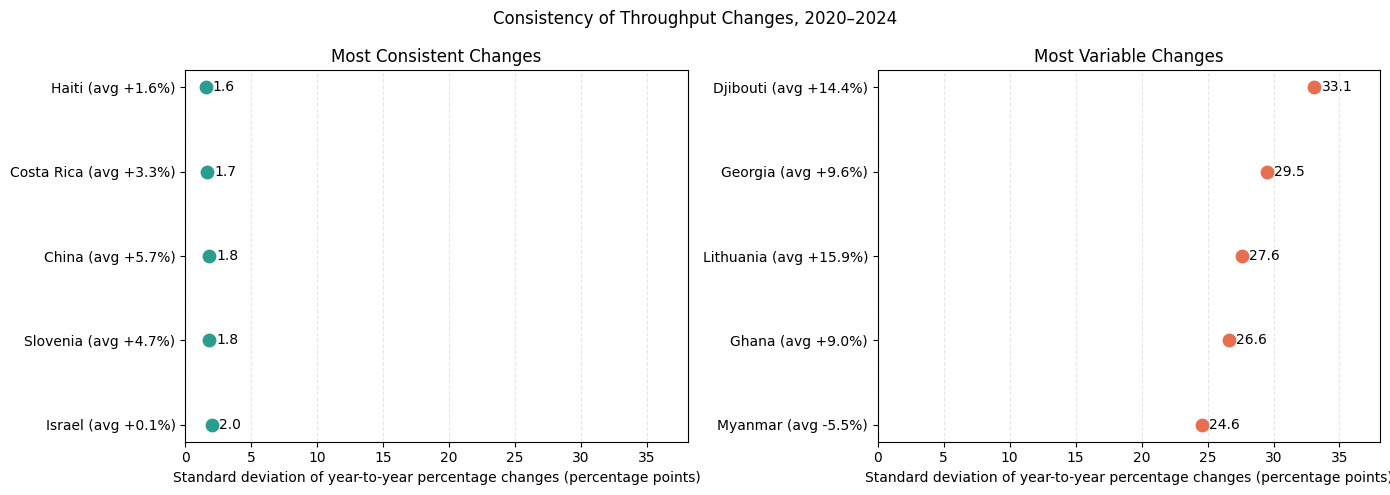

In [28]:
import matplotlib.pyplot as plt

q5_df = complete_df.sort_values(["Economy_Label", "Year"]).copy()

q5_df["YoY_Change_Percent"] = (
    q5_df.groupby("Economy_Label")[value_col]
    .pct_change(fill_method=None) * 100
)

q5_metrics = (
    q5_df.dropna(subset=["YoY_Change_Percent"])
    .groupby("Economy_Label")
    .agg(
        Mean_YoY_Change_Percent=("YoY_Change_Percent", "mean"),
        SD_YoY_Change_Percent=("YoY_Change_Percent", "std")
    )
    .reset_index()
)

# Order each panel so its most extreme economy appears at the top
most_consistent = q5_metrics.nsmallest(
    5, "SD_YoY_Change_Percent"
).sort_values("SD_YoY_Change_Percent", ascending=False)

most_variable = q5_metrics.nlargest(
    5, "SD_YoY_Change_Percent"
).sort_values("SD_YoY_Change_Percent", ascending=True)

print("Economies compared:", len(q5_metrics))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

x_max = q5_metrics["SD_YoY_Change_Percent"].max() * 1.15
if x_max == 0:
    x_max = 1

panels = [
    (axes[0], most_consistent, "Most Consistent Changes", "#2A9D8F"),
    (axes[1], most_variable, "Most Variable Changes", "#E76F51")
]

for ax, data, title, color in panels:
    positions = range(len(data))

    labels = [
        f"{country} (avg {mean_change:+.1f}%)"
        for country, mean_change in zip(
            data["Economy_Label"],
            data["Mean_YoY_Change_Percent"]
        )
    ]

    ax.scatter(
        data["SD_YoY_Change_Percent"],
        positions,
        color=color,
        s=80
    )

    ax.set_yticks(list(positions))
    ax.set_yticklabels(labels)
    ax.set_xlim(0, x_max)
    ax.set_title(title)
    ax.set_xlabel(
        "Standard deviation of year-to-year percentage changes "
        "(percentage points)"
    )
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    for x_value, y_position in zip(
        data["SD_YoY_Change_Percent"], positions
    ):
        ax.annotate(
            f"{x_value:.1f}",
            (x_value, y_position),
            xytext=(5, 0),
            textcoords="offset points",
            va="center"
        )

fig.suptitle("Consistency of Throughput Changes, 2020–2024")
plt.tight_layout()
plt.show()

**How to read the chart:** Each dot represents an economy. The horizontal axis shows how much its year-to-year percentage changes varied from 2020 to 2024, measured in percentage points. Dots farther left indicate more consistent changes; dots farther right indicate more variable changes. The average annual percentage change shown beside each economy gives context about its overall direction of change.



### **Q5 Finding — Consistency of Year-to-Year Percentage Changes**

Among the 101 economies compared, **Haiti** had the most consistent year-to-year percentage changes (standard deviation: **1.6 percentage points**; average annual change: **+1.6%**). **Djibouti** had the most variable changes (standard deviation: **33.1 percentage points**; average annual change: **+14.4%**). Djibouti’s average does not mean its throughput increased by 14.4% in every year; its annual rates varied substantially.

## **Overall Conclusion**

China had the highest reported container port throughput in 2024 and remained in first place from 2020 to 2024. The top five economies kept their rankings, while some others moved: Viet Nam rose from 11th to 6th. Among economies with reported values in both 2020 and 2024, China had the largest absolute increase, while Côte d’Ivoire had the largest percentage increase.

For the 101 economies with reported values in every year, combined throughput rose from 781.0 million TEUs in 2020 to 907.2 million TEUs in 2024—an increase of about 16.2%. Year-to-year changes varied across economies: Haiti’s changes were the most consistent, while Djibouti’s were the most variable.

These findings describe reported container port throughput, measured in TEUs. They do not measure each country’s overall economic performance, and the combined five-year trend covers only the 101 economies with complete data.

## **Recommendations**

1. **Use absolute changes to identify where throughput increased most.** China had the largest absolute increase from 2020 to 2024. Treat this as a signal for further capacity review, alongside port-level capacity and utilization data.
2. **Investigate economies with high percentage growth.** Côte d’Ivoire had the largest percentage increase. Check the starting throughput and port-level trends before interpreting this as a major change in overall volume.
3. **Review economies with highly variable annual changes.** Djibouti had the most variable year-to-year percentage changes. Compare this pattern with port operations and trade data to understand what may be driving the fluctuations.
4. **Improve data coverage for future comparisons.** The five-year combined trend includes 101 economies with reported values for every year; additional complete data would make global comparisons more representative.

## **Limitations**

- The data is reported at the economy level, so it does not show differences between individual ports or shipping companies.
- Some throughput values are unavailable. The five-year combined trend includes only the 101 economies with reported values for every year.
- The analysis covers 2020–2024 and describes observed changes; it does not explain their causes or predict future throughput.

## **References**

UNCTADstat. *Container port throughput, annual (analytical).* [Dataset page](https://unctadstat.unctad.org/datacentre/reportInfo/US.ContPortThroughput).